In [11]:
# 1:导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif']=['SimHei']


In [12]:
# 2：导入数据
df=pd.read_csv('data/house_data.csv')


In [13]:
# 3：数据概览
print('总记录数字:',len(df))
print('字段的数量:',len(df.columns))
df.head(5)
df.info()


总记录数字: 399
字段的数量: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   city        399 non-null    object
 1   address     399 non-null    object
 2   area        397 non-null    object
 3   floor       397 non-null    object
 4   name        398 non-null    object
 5   price       398 non-null    object
 6   province    399 non-null    object
 7   rooms       398 non-null    object
 8   toward      399 non-null    object
 9   unit        399 non-null    object
 10  year        396 non-null    object
 11  origin_url  399 non-null    object
dtypes: object(12)
memory usage: 37.5+ KB


In [14]:
# 4：数据清洗
#删除不需要的列 inplace=Tru,立即生效
df.drop(columns='origin_url',inplace=True) 
# 5：新数据特征构造
# 6：问题分析以及可视化

In [15]:
#检查缺失值
df.isna().sum()
#删除缺失值
df.dropna(inplace=True)


In [16]:
print(len(df))
print('再次检查缺失值：',df.isna().sum())

390
再次检查缺失值： city        0
address     0
area        0
floor       0
name        0
price       0
province    0
rooms       0
toward      0
unit        0
year        0
dtype: int64


In [17]:
#检查是否有重复值
print(df.duplicated().sum())
print(len(df))

11
390


In [18]:
#删除重复数据
print(df.drop_duplicates(inplace=True))
print(len(df))

None
379


In [19]:
# df.head()
df['area'] = df['area'].astype(str)
#面积是护具类型转换
df['area']=pd.to_numeric(df['area'].str.replace('㎡',''),errors='coerce') #将area这一列的异常值做处理
# 根据索引删除异常值
print('删除前:',len(df))
# df=df.drop(163) #删除这一条垃圾数据
print('删除前:',len(df))
df.head()

删除前: 379
删除前: 379


,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125万,安徽,3室2厅,南北通透,13966元/㎡,2015
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160万,安徽,3室2厅,朝南,14545元/㎡,2010
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190万,安徽,3室2厅,南北通透,15574元/㎡,2012
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218万,安徽,4室2厅,朝南,16769元/㎡,2016
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140万,安徽,3室1厅,朝西,14894元/㎡,2011


In [20]:
#售价的类型转换

# df.dropna(inplace=True)
# df.isna().sum()
# df['price']=df['price'].str.replace('万','').astype(float)
# df.head()
# pd.to_numeric(df['price'].astype(str).str('万','',regex=False),errors='coerce')
df['price']=pd.to_numeric(
    df['price'].astype(str).str.replace('万', '', regex=False),
    errors='coerce'
)
df.head()


,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966元/㎡,2015
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545元/㎡,2010
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574元/㎡,2012
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769元/㎡,2016
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894元/㎡,2011


In [21]:
#朝向数据类型处理
df['toward'].value_counts()


toward
朝南        80
朝东        72
朝西        70
朝北        65
南北向       50
南北通透      40
南北         1
toward     1
Name: count, dtype: int64

In [22]:
df['toward']=df['toward'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379 entries, 0 to 398
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      379 non-null    object  
 1   address   379 non-null    object  
 2   area      377 non-null    float64 
 3   floor     379 non-null    object  
 4   name      379 non-null    object  
 5   price     378 non-null    float64 
 6   province  379 non-null    object  
 7   rooms     379 non-null    object  
 8   toward    379 non-null    category
 9   unit      379 non-null    object  
 10  year      379 non-null    object  
dtypes: category(1), float64(2), object(8)
memory usage: 33.3+ KB


In [23]:
#每平米单价unit处理
df['unit']=pd.to_numeric(
    df['unit'].astype(str).str.replace('元/㎡', '', regex=False),
    errors='coerce'
)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966.0,2015
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545.0,2010
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574.0,2012
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769.0,2016
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894.0,2011


In [24]:
# 建造年份year转换为int类型
df['year']=pd.to_numeric(
    df['year'].astype(str).str.replace('年建', '', regex=False),
    errors='coerce'
)
df.head()


,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966.0,2015.0
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545.0,2010.0
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574.0,2012.0
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769.0,2016.0
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894.0,2011.0


In [25]:
#异常值的处理
# 房屋面积的异常处理
df[df['area']>500]

,city,address,area,floor,name,price,province,rooms,toward,unit,year
153,杭州,余杭区未来科技城,555.0,中层/26层,顶墅大平层,1880.0,浙江,6室4厅,南北通透,33874.0,2020.0


In [26]:
# 房屋售价的异常值处理IQR
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
low_price=Q1-1.5*IQR
high_price=Q3+1.5*IQR
df[df['price']<low_price]
df[df['price']>high_price]

,city,address,area,floor,name,price,province,rooms,toward,unit,year
42,南京,建邺区奥体大街,129.0,高层/32层,仁恒江湾城,515.0,江苏,4室2厅,南北通透,39922.0,2012.0
52,南京,建邺区庐山路,124.0,高层/30层,中海塞纳丽舍,435.0,江苏,4室2厅,南北通透,35081.0,2009.0
62,杭州,下城区庆春路,119.0,中层/26层,东河家园,475.0,浙江,3室2厅,南北通透,39916.0,2008.0
74,杭州,滨江区闻涛路,129.0,高层/33层,太阳国际,516.0,浙江,4室2厅,南北通透,39999.0,2009.0
91,苏州,工业园区星湖街,109.0,高层/33层,玲珑湾,438.0,江苏,3室2厅,南北通透,40183.0,2008.0
101,苏州,工业园区星塘街,119.0,高层/32层,东方之门,715.0,江苏,4室2厅,朝南,59999.0,2012.0
131,无锡,滨湖区望山路,119.0,高层/32层,蠡湖香樟园,476.0,江苏,4室2厅,朝南,39999.0,2013.0
153,杭州,余杭区未来科技城,555.0,中层/26层,顶墅大平层,1880.0,浙江,6室4厅,南北通透,33874.0,2020.0
154,苏州,工业园区金鸡湖,199.0,高层/30层,湖景大平层,1280.0,江苏,5室2厅,朝南,64322.0,2015.0
155,无锡,滨湖区蠡湖,266.0,中层/26层,湖景别墅,880.0,江苏,5室3厅,南北通透,33083.0,2014.0


In [27]:
# 5：新数据特征点构造
# 地区district
df['district']=df['address'].str.split('-').str[0]
df['district']=df['address'].str.split('').str[0]
df.head(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966.0,2015.0,
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545.0,2010.0,
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574.0,2012.0,
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769.0,2016.0,
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894.0,2011.0,


In [28]:
# 楼层类型floor_type
# df['floor_type']=df['floor'].str.split('(').str[0]
#正则表达式转换高层/30层和高层(共30层)这两种类型的数据
df['floor_type']=df['floor'].str.split(r'[\(/]').str[0].astype('category')
# 中层(共24层)
df.head()
# 卧室的数量bedrooms
# 客厅的数量livingrooms
# 楼龄building_age
# 价格的区间price_labels    

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966.0,2015.0,,中层
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545.0,2010.0,,高层
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574.0,2012.0,,中层
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769.0,2016.0,,高层
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894.0,2011.0,,低层


In [29]:
#第二种方式处理floor
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    return '未知'

df['floor_type2']=df['floor'].apply(fun1).astype('category')

In [30]:
#是否是直辖市
df['zxs']=df['city'].apply(lambda x:1 if x in ['北京','上海','天津','重庆'] else 0)

In [41]:
#卧室数量
df.drop(152,inplace=True)
# df['badrooms']=df['rooms'].str.split('室').str[0].astype(int)
# df.sample(10)

In [42]:
#客厅数量
# df['livingrooms']=df['rooms'].str.extract(r'(\d+)厅').astype(int)
# df['rooms'].str.extract(r'(\d+)厅').astype(int)
# df['rooms'].astype(str).str.extract(r'(\d+)厅').astype(int)
# df['rooms'].fillna('').astype(str).str.extract(r'(\d+)厅').astype(int)
df['livingrooms'] = pd.to_numeric(
    df['rooms'].astype(str).str.extract(r'(\d+)厅')[0],
    errors='coerce'
).fillna(0).astype(int)
# df.sample(10)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_type2,zxs,livingrooms
0,合肥,瑶海区长江东路188号,89.5,中层/18层,保利东郡,125.0,安徽,3室2厅,南北通透,13966.0,2015.0,,中层,中楼层,0,2
1,合肥,蜀山区望江西路,110.0,高层/33层,拓基城市广场,160.0,安徽,3室2厅,朝南,14545.0,2010.0,,高层,高楼层,0,2
3,合肥,庐阳区北一环,122.0,中层/24层,财富广场,190.0,安徽,3室2厅,南北通透,15574.0,2012.0,,中层,中楼层,0,2
5,合肥,高新区创新大道,130.0,高层/30层,祥源城,218.0,安徽,4室2厅,朝南,16769.0,2016.0,,高层,高楼层,0,2
6,合肥,经开区繁华大道,94.0,低层/11层,中环云邸,140.0,安徽,3室1厅,朝西,14894.0,2011.0,,低层,低楼层,0,1


In [43]:
#计算楼龄
df['builiding_age']=2026-df['year']

In [44]:
df.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_type2,zxs,livingrooms,builiding_age
25,合肥,高新区科学大道,127.0,高层/30层,百商悦澜山,212.0,安徽,4室2厅,朝南,16693.0,2014.0,,高层,高楼层,0,2,12.0
301,无锡,梁溪-五爱路与人民路交口,88.0,低层(共11层),五爱小区,211.0,江苏,2室2厅,朝东,24000.0,2005.0,,低层,低楼层,0,2,21.0
172,合肥,蜀山-潜山路与黄山路交口,105.0,高层(共32层),华润幸福里,179.0,安徽,3室2厅,朝南,17048.0,2014.0,,高层,高楼层,0,2,12.0
77,杭州,钱塘区下沙路,84.0,高层/30层,下沙碧桂园,168.0,浙江,2室2厅,朝东,20000.0,2017.0,,高层,高楼层,0,2,9.0
335,合肥,瑶海-明光路与长江东大街交口,92.0,中层(共24层),恒大城,138.0,安徽,3室1厅,南北向,15000.0,2013.0,,中层,中楼层,0,1,13.0


In [45]:
#价格分段
df['price_labels']=pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])

In [46]:
df.sample(10)


,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_type2,zxs,livingrooms,builiding_age,price_labels
113,苏州,吴中区越溪街,91.0,中层/18层,越溪小区,164.0,江苏,3室1厅,朝西,18022.0,2012.0,,中层,中楼层,0,1,14.0,低价
25,合肥,高新区科学大道,127.0,高层/30层,百商悦澜山,212.0,安徽,4室2厅,朝南,16693.0,2014.0,,高层,高楼层,0,2,12.0,低价
235,杭州,上城-庆春东路与钱江路交口,102.0,高层(共32层),钱江新城小区,408.0,浙江,3室2厅,朝南,40000.0,2012.0,,高层,高楼层,0,2,14.0,低价
96,苏州,昆山市前进路,99.0,中层/26层,昆山万达,198.0,江苏,3室2厅,朝南,20000.0,2016.0,,中层,中楼层,0,2,10.0,低价
52,南京,建邺区庐山路,124.0,高层/30层,中海塞纳丽舍,435.0,江苏,4室2厅,南北通透,35081.0,2009.0,,高层,高楼层,0,2,17.0,低价
90,苏州,姑苏区干将路,99.0,中层/24层,养育巷小区,318.0,江苏,3室1厅,朝南,32121.0,2004.0,,中层,中楼层,0,1,22.0,低价
104,苏州,相城区春申湖路,85.0,低层/11层,春申湖小区,136.0,江苏,2室2厅,朝北,16000.0,2013.0,,低层,低楼层,0,2,13.0,低价
239,杭州,萧山-金城路与青年路交口,90.0,中层(共18层),汇德隆银隆百货,243.0,浙江,3室1厅,朝北,27000.0,2014.0,,中层,中楼层,0,1,12.0,低价
198,南京,雨花-雨花西路与安德门大街交口,90.0,中层(共18层),时光澔韵,225.0,江苏,3室1厅,朝北,25000.0,2012.0,,中层,中楼层,0,1,14.0,低价
15,合肥,包河区宿松路,77.0,高层/33层,铂金汉宫,105.0,安徽,2室1厅,朝南,13636.0,2010.0,,高层,高楼层,0,1,16.0,低价


e:\workspace\python_script\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()
e:\workspace\python_script\.venv\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
e:\workspace\python_script\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


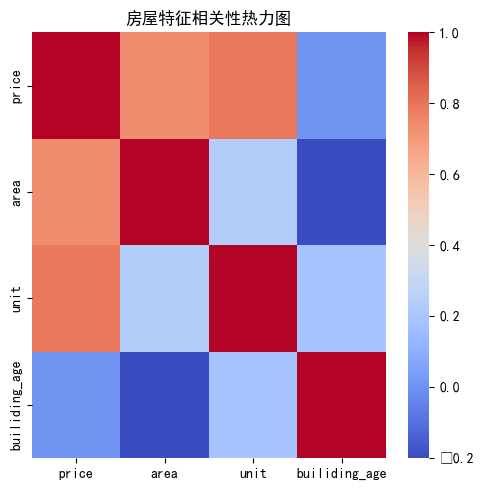

In [58]:
# 选择数据值特征
a=df[['price','area','unit','builiding_age']].corr()
#对房价影响最大的几个因素
a['price'].sort_values(ascending=False)[1:]  #降序排列,然后切片
#相关性的热力图
plt.figure(figsize=(5,5))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()


In [59]:
#房价的总体分布是怎么样
df.describe()

,area,price,unit,year,zxs,livingrooms,builiding_age
count,377.000000,377.000000,377.000000,377.000000,378.0,378.000000,377.000000
mean,99.196286,214.511936,20897.047745,2010.538462,0.0,1.584656,15.461538
std,31.399281,154.508178,9973.120029,4.926506,0.0,0.529729,4.926506
min,42.500000,28.000000,2314.000000,2001.000000,0.0,0.000000,6.000000
25%,85.000000,130.000000,14000.000000,2006.000000,0.0,1.000000,11.000000
50%,95.000000,179.000000,17031.000000,2011.000000,0.0,2.000000,15.000000
75%,108.000000,248.000000,26000.000000,2015.000000,0.0,2.000000,20.000000
max,555.000000,1880.000000,116163.000000,2020.000000,0.0,4.000000,25.000000


(array([233., 118.,  19.,   3.,   1.,   1.,   1.,   0.,   0.,   1.]),
 array([  28. ,  213.2,  398.4,  583.6,  768.8,  954. , 1139.2, 1324.4,
        1509.6, 1694.8, 1880. ]),
 <BarContainer object of 10 artists>)

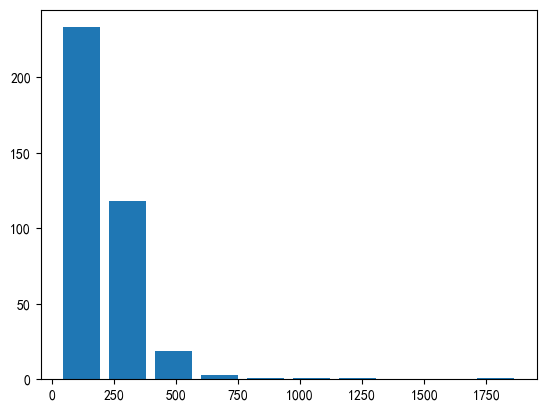

In [67]:
#房价直方图进行分析
plt.subplot(1,1,1)
plt.hist(df['price'],bins=10,rwidth=0.8)



<Axes: xlabel='price', ylabel='Count'>

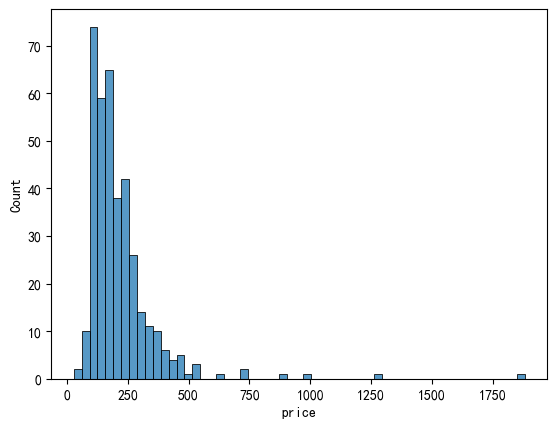

In [69]:
sns.histplot(data=df,x='price')

<Axes: xlabel='price', ylabel='Count'>

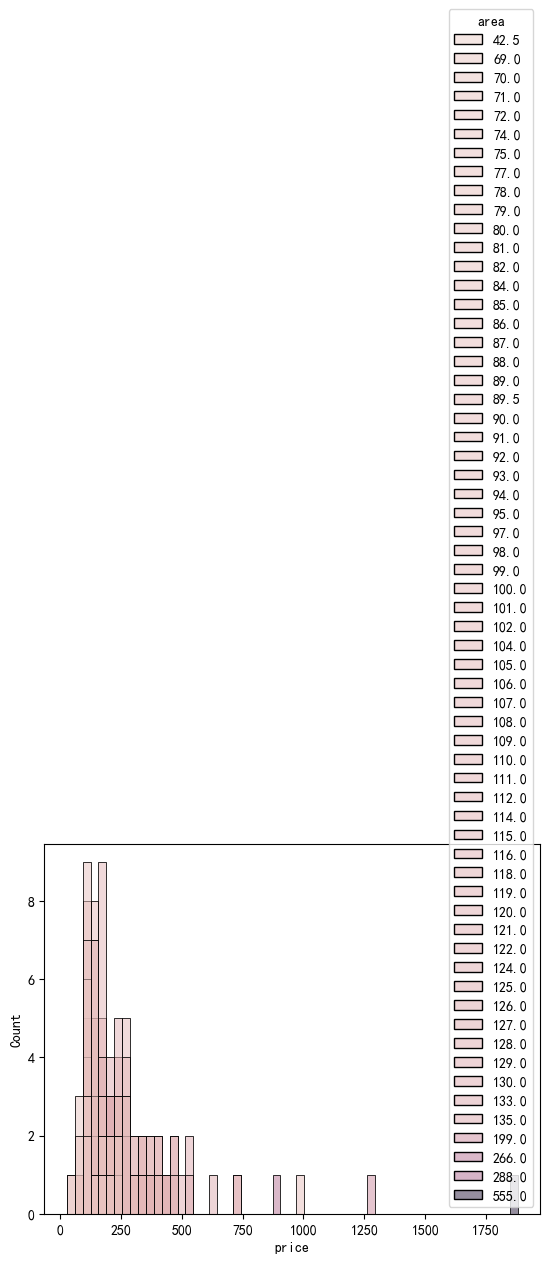

In [70]:
sns.histplot(data=df,x='price',hue='area')

<Axes: xlabel='price', ylabel='Count'>

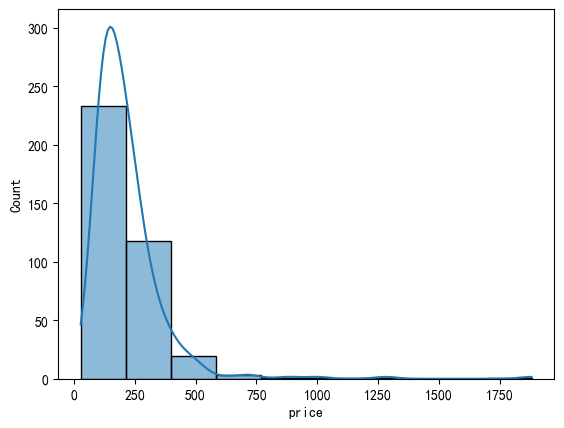

In [71]:
#分为是十个等分，设置核密度线
sns.histplot(data=df,x='price',bins=10,kde=True)

In [83]:
#房屋朝向分析
#   
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'median',
    'builiding_age':'mean',
})

price            unit builiding_age
              mean median   median          mean
toward                                          
toward         NaN    NaN      NaN           NaN
南北             NaN    NaN      NaN           NaN
南北向     239.740000  214.0  20000.0     15.920000
南北通透    341.200000  253.0  25556.5     15.500000
朝东      186.486111  183.0  20000.0     17.722222
朝北      158.523077  136.0  15000.0     13.415385
朝南      252.000000  211.0  19000.0     14.625000
朝西      162.071429  135.0  15000.0     15.642857

In [82]:
print(f"删除前形状: {df.shape}")
print(f"删除后形状: {df.shape}")

删除前形状: (377, 18)
删除后形状: (377, 18)


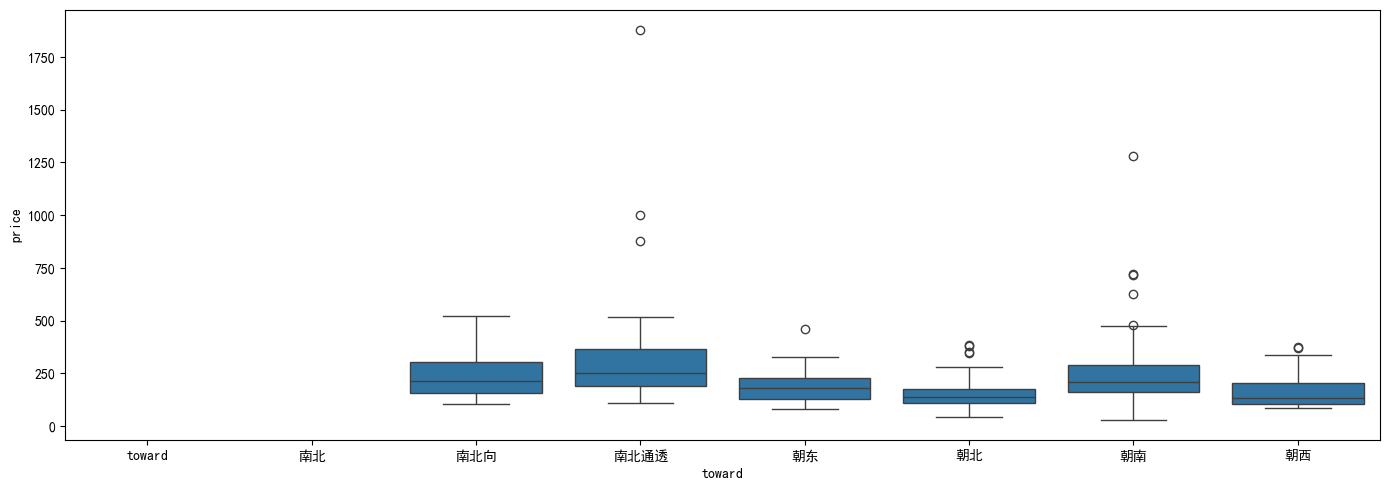

In [85]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='toward',y='price')
plt.tight_layout()

In [87]:
df['toward'].value_counts()

toward
朝南        80
朝东        72
朝西        70
朝北        65
南北向       50
南北通透      40
toward     0
南北         0
Name: count, dtype: int64